# Term Deposit Marketing Notebook

## 1. Background/Introduction

We are a small startup focusing mainly on providing machine learning solutions in the European banking market. We work on a variety of problems including fraud detection, sentiment classification and customer intention prediction and classification.

We are interested in developing a robust machine learning system that leverages information coming from call center data.

Ultimately, we are looking for ways to improve the success rate for calls made to customers for any product that our clients offer. Towards this goal we are working on designing an ever evolving machine learning product that offers high success outcomes while offering interpretability for our clients to make informed decisions.

The data comes from direct marketing efforts of a European banking institution. The marketing campaign involves making a phone call to a customer, often multiple times to ensure a product subscription, in this case a term deposit. Term deposits are usually short-term deposits with maturities ranging from one month to a few years. The customer must understand when buying a term deposit that they can withdraw their funds only after the term ends. All customer information that might reveal personal information is removed due to privacy concerns.

age : age of customer (numeric)

job : type of job (categorical)

marital : marital status (categorical)

education (categorical)

default: has credit in default? (binary)

balance: average yearly balance, in euros (numeric)

housing: has a housing loan? (binary)

loan: has personal loan? (binary)

contact: contact communication type (categorical)

day: last contact day of the month (numeric)

month: last contact month of year (categorical)

duration: last contact duration, in seconds (numeric)

campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)

Output (desired target):

y - has the client subscribed to a term deposit? (binary)



In [2]:
pip install scikit-learn

  Using cached scikit_learn-1.9.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
Using cached scikit_learn-1.9.0-cp312-cp312-win_amd64.whl (8.2 MB)
Note: you may need to restart the kernel to use updated packages.


## 2. Data Exploration (EDA)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score


# Load the dataset
df = pd.read_csv("data/term-deposit-marketing-2020.csv")

In [4]:
#DATA EXPLORATION
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        40000 non-null  int64 
 1   job        40000 non-null  object
 2   marital    40000 non-null  object
 3   education  40000 non-null  object
 4   default    40000 non-null  object
 5   balance    40000 non-null  int64 
 6   housing    40000 non-null  object
 7   loan       40000 non-null  object
 8   contact    40000 non-null  object
 9   day        40000 non-null  int64 
 10  month      40000 non-null  object
 11  duration   40000 non-null  int64 
 12  campaign   40000 non-null  int64 
 13  y          40000 non-null  object
dtypes: int64(5), object(9)
memory usage: 4.3+ MB


In [5]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no


In [6]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
39995,53,technician,married,tertiary,no,395,no,no,cellular,3,jun,107,1,no
39996,30,management,single,tertiary,no,3340,no,no,cellular,3,jun,238,3,yes
39997,54,admin,divorced,secondary,no,200,no,no,cellular,3,jun,170,1,yes
39998,34,management,married,tertiary,no,1047,no,no,cellular,3,jun,342,1,no
39999,38,technician,married,secondary,no,1442,yes,no,cellular,3,jun,113,1,no


In [7]:
df.shape

(40000, 14)

In [8]:
df.describe(include="all")

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
count,40000.000000,40000,40000,40000,40000,40000.000000,40000,40000,40000,40000.000000,40000,40000.000000,40000.000000,40000
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,11,NaN,NaN,2
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,no
freq,NaN,9383,24386,20993,39191,NaN,24031,33070,24914,NaN,13532,NaN,NaN,37104
mean,40.544600,NaN,NaN,NaN,NaN,1274.277550,NaN,NaN,NaN,16.017225,NaN,254.824300,2.882175,NaN
std,9.641776,NaN,NaN,NaN,NaN,2903.769716,NaN,NaN,NaN,8.278127,NaN,259.366498,3.239051,NaN
min,19.000000,NaN,NaN,NaN,NaN,-8019.000000,NaN,NaN,NaN,1.000000,NaN,0.000000,1.000000,NaN
25%,33.000000,NaN,NaN,NaN,NaN,54.000000,NaN,NaN,NaN,8.000000,NaN,100.000000,1.000000,NaN
50%,39.000000,NaN,NaN,NaN,NaN,407.000000,NaN,NaN,NaN,17.000000,NaN,175.000000,2.000000,NaN
75%,48.000000,NaN,NaN,NaN,NaN,1319.000000,NaN,NaN,NaN,21.000000,NaN,313.000000,3.000000,NaN


In [9]:
# Check missing values
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
y            0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df["y"].value_counts()

y
no     37104
yes     2896
Name: count, dtype: int64

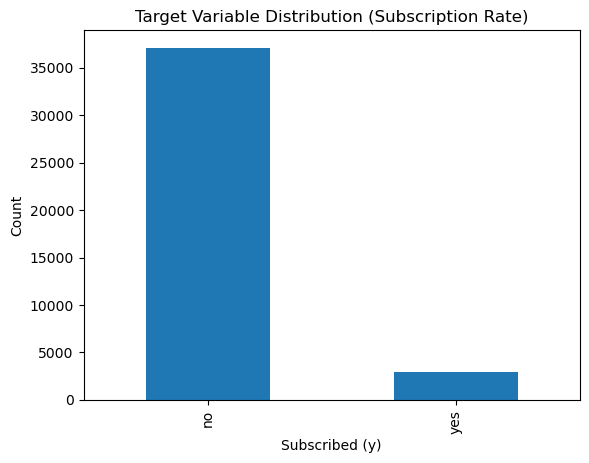

In [12]:
df["y"].value_counts().plot(kind="bar")
plt.title("Target Variable Distribution (Subscription Rate)")
plt.xlabel("Subscribed (y)")
plt.ylabel("Count")
plt.show()

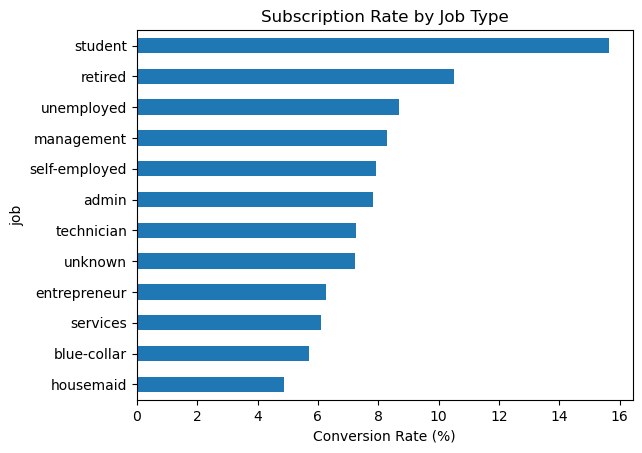

In [13]:
job_rate = pd.crosstab(df["job"], df["y"], normalize="index") * 100
job_rate = job_rate.sort_values("yes", ascending=False)
job_rate["yes"].sort_values().plot(kind="barh")
plt.title("Subscription Rate by Job Type")
plt.xlabel("Conversion Rate (%)")
plt.show()

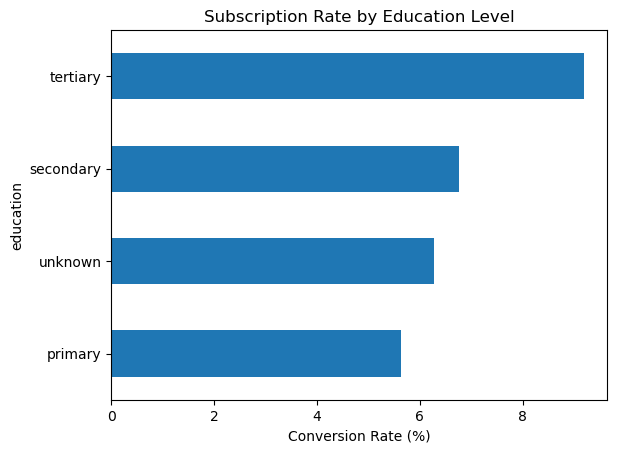

In [14]:
edu_rate = pd.crosstab(df["education"], df["y"], normalize="index") * 100
edu_rate["yes"].sort_values().plot(kind="barh")
plt.title("Subscription Rate by Education Level")
plt.xlabel("Conversion Rate (%)")
plt.show()

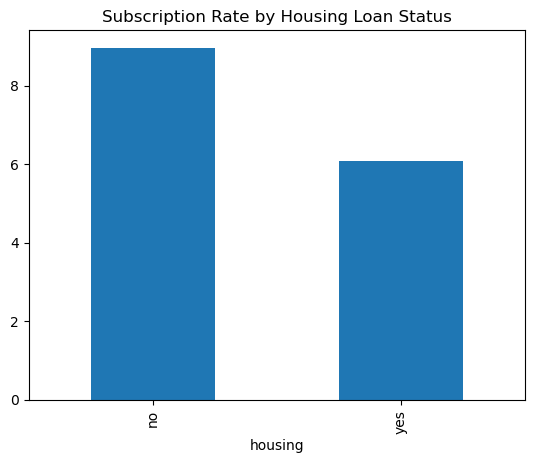

In [15]:
pd.crosstab(df["housing"], df["y"], normalize="index") * 100
housing_rate = pd.crosstab(df["housing"], df["y"], normalize="index") * 100
housing_rate["yes"].plot(kind="bar")
plt.title("Subscription Rate by Housing Loan Status")
plt.show()

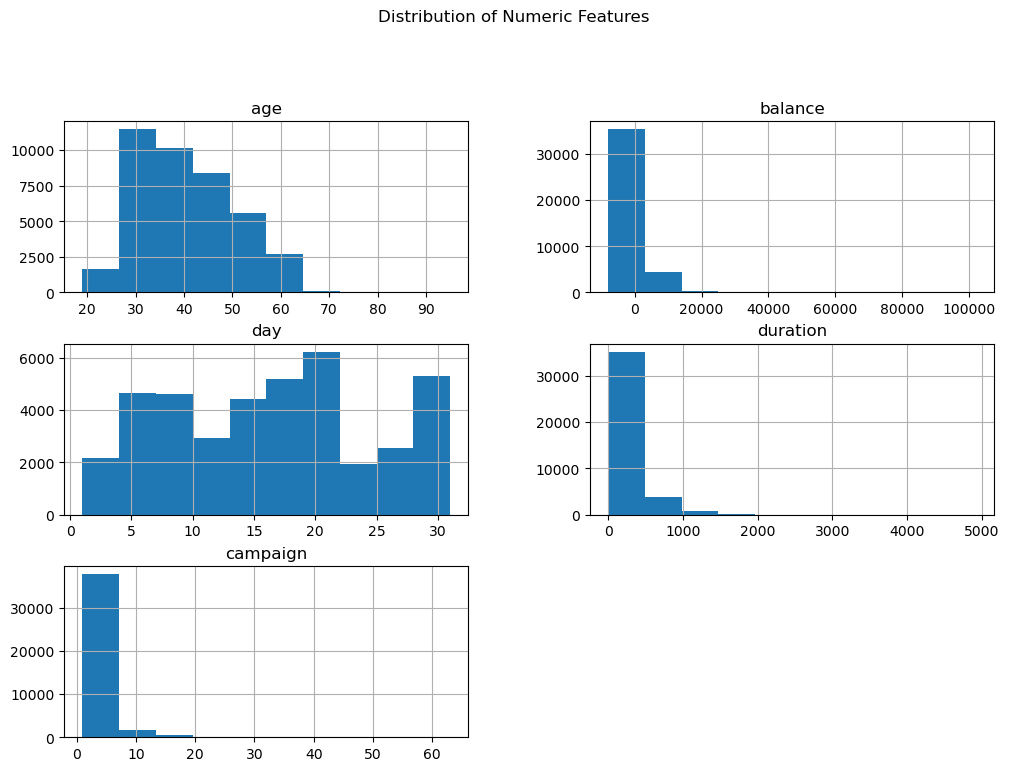

In [16]:
df.hist(figsize=(12,8))
plt.suptitle("Distribution of Numeric Features", y=1.02)
plt.show()

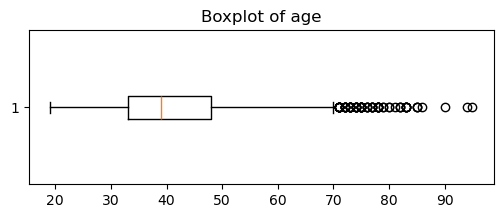

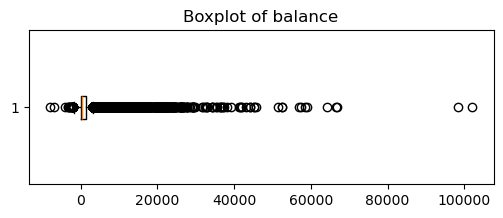

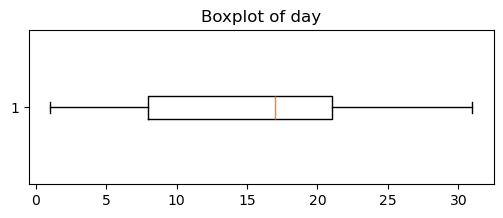

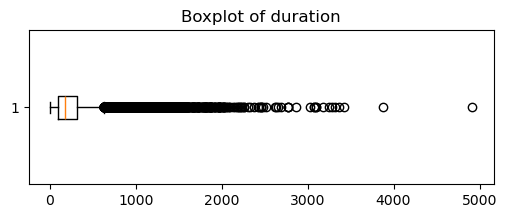

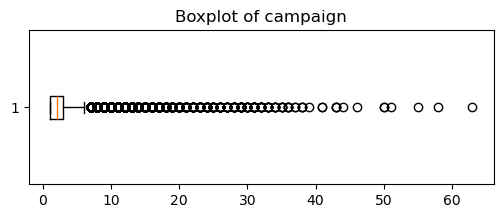

In [17]:
numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    plt.figure(figsize=(6,2))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot of {col}")
    plt.show()

### Target Distribution and Customer Characteristics

- The target variable (`y`) is highly imbalanced, with approximately 93% of customers not subscribing and only 7% subscribing. This indicates that accuracy alone may be misleading, as a model could achieve high accuracy by predicting the majority class.

- Subscription rates differ noticeably across job categories. Students have the highest conversion rate (approximately 16%), followed by retired and unemployed customers, while housemaids and blue-collar workers exhibit the lowest conversion rates. This suggests that occupation contains useful predictive information.

- Education level also shows a relationship with subscription likelihood. Customers with tertiary education have the highest conversion rate, while those with primary education have the lowest. Although the differences are smaller than those observed for job type, education may still contribute to prediction performance.

- Housing Loan status also seemed to be a determinant, as lack of housing loan generally coincides with more expendable income and therefore links with a higher chance of buying a term deposit.

- The numeric distribution plots showed that most values outside of 'day' are focused in small ranges, while the box plots helped show that for many features, such as campaign, duration and especially balance, there can be extreme outliers that can skew the data.

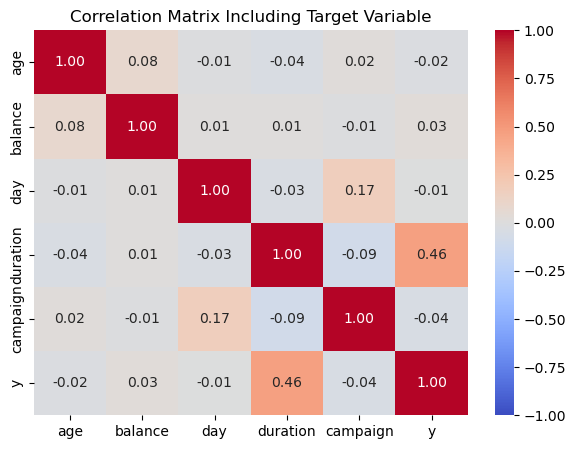

In [18]:
corr_df = df.copy()
corr_df["y"] = corr_df["y"].map({"no": 0, "yes": 1})
corr_cols = numeric_cols.tolist() + ["y"]

# Plot correlation matrix
plt.figure(figsize=(7,5))
sns.heatmap(
    corr_df[corr_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1
)
plt.title("Correlation Matrix Including Target Variable")
plt.show()

### Correlation Analysis

- A correlation matrix was used to examine the linear relationships between the numerical features and the target variable.
- Duration showed the strongest correlation with subscription (0.46), indicating that longer calls are associated with a higher likelihood of subscribing. As duration is only known after a call, it was excluded from the first-layer model.
- The strongest relationships between numerical features were campaign and day (0.17), followed by balance and age (0.08).
- Overall, correlations between the remaining features were weak, suggesting minimal multicollinearity.

In [19]:
df_encoded = df.copy()

for col in df_encoded.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

X = df_encoded.drop("y", axis=1)
y = df_encoded["y"]

mi = mutual_info_classif(X, y, random_state=42)

importance = (
    pd.Series(mi, index=X.columns)
    .sort_values(ascending=False)
)

print(importance)

duration     0.077583
month        0.012680
contact      0.008609
housing      0.007544
education    0.005913
age          0.005791
marital      0.005452
job          0.004435
day          0.003085
balance      0.003021
campaign     0.002088
loan         0.000592
default      0.000000
dtype: float64


### Mutual Information Analysis

- Mutual Information was used to measure the predictive value of each feature, capturing both linear and non-linear relationships.
- Duration was the most informative feature (0.0776), followed by month (0.0127), contact type (0.0086), housing (0.0075), education (0.0059), and age (0.0058).
- Features such as campaign, loan, and default contributed very little predictive information.
- These results helped guide feature selection and supported the use of a second-layer model that incorporates duration after the initial customer call.

## EDA Summary

- The dataset contains a mixture of numerical and categorical features with no missing values, requiring only categorical encoding before modelling.
- The target variable is highly imbalanced, with approximately 93% of customers not subscribing, making metrics such as recall and precision important alongside accuracy.
- Customer characteristics such as job type, education level, month of contact, and contact method showed noticeable differences in subscription rates, suggesting they are useful predictors.
- Correlation analysis identified duration as the strongest numerical predictor of subscription, while Mutual Information confirmed duration as the most informative feature overall.
- Based on these findings, three modelling approaches were developed: an accuracy focused base model, a first-layer model using only pre-call customer information and a second-layer model incorporating call duration after the initial customer interaction to improve prediction performance.

## 3. Models 

### Baseline Model (Purchase Prediction Without Duration and Campaign)

In [20]:
X_encoded = X.copy()

X_encoded = df.drop(columns=["y", "duration", "campaign"])
y = df["y"]

categorical_cols = X_encoded.select_dtypes(include="object").columns

encoder = OrdinalEncoder()
X_encoded[categorical_cols] = encoder.fit_transform(X_encoded[categorical_cols])

In [21]:
model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred = cross_val_predict(
    model,
    X_encoded,
    y,
    cv=cv
)

scores = cross_val_score(
    model,
    X_encoded,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Fold accuracies:", scores)
print("Mean accuracy:", scores.mean())

from sklearn.metrics import recall_score

recall_yes = recall_score(y, y_pred, pos_label="yes")

print("Recall (YES class):", recall_yes)

Fold accuracies: [0.927125 0.92925  0.92675  0.927375 0.92775 ]
Mean accuracy: 0.9276500000000001
Recall (YES class): 0.0231353591160221


### Baseline Model Findings
Although the model achieves high accuracy (~93%), this is driven by class imbalance in the dataset. The model fails to identify positive cases, achieving a recall of only ~2%, indicating that accuracy is not a suitable metric for this problem. 

### Multi-Layer Recall Model (Call Reduction and Purchase Retention)

### Layer 1

In [23]:
df_model = df.copy()

y = df_model["y"].map({"yes": 1, "no": 0})

X = df_model.drop(columns=["y", "duration"])

# encode categoricals
cat_cols = X.select_dtypes(include="object").columns

encoder = OrdinalEncoder()
X[cat_cols] = encoder.fit_transform(X[cat_cols])

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
def objective(params):

    model = RandomForestClassifier(
        n_estimators=int(params["n_estimators"]),
        max_depth=int(params["max_depth"]),
        min_samples_leaf=int(params["min_samples_leaf"]),
        min_samples_split=int(params["min_samples_split"]),
        max_features=params["max_features"],
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="recall"
    ).mean()

    return {
        "loss": -score,
        "status": STATUS_OK
    }

In [26]:
space = {
    "n_estimators": hp.quniform("n_estimators", 200, 800, 50),
    "max_depth": hp.quniform("max_depth", 5, 20, 1),
    "min_samples_leaf": hp.quniform("min_samples_leaf", 1, 30, 1),
    "min_samples_split": hp.quniform("min_samples_split", 2, 60, 2),
    "max_features": hp.choice("max_features", ["sqrt", "log2"])
}

In [27]:
trials = Trials()

best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=40,
    trials=trials,
    rstate=np.random.default_rng(42)
)

print(best)

100%|██████████| 40/40 [09:38<00:00, 14.45s/trial, best loss: -0.6163150741044164]
{'max_depth': 5.0, 'max_features': 0, 'min_samples_leaf': 18.0, 'min_samples_split': 20.0, 'n_estimators': 550.0}


In [28]:
feature_options = ["sqrt", "log2"]

model = RandomForestClassifier(
    n_estimators=int(best["n_estimators"]),
    max_depth=int(best["max_depth"]),
    min_samples_leaf=int(best["min_samples_leaf"]),
    min_samples_split=int(best["min_samples_split"]),
    max_features=feature_options[best["max_features"]],
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",550
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",18
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fea

In [29]:
y_prob = model.predict_proba(X_test)[:, 1]

results = X_test.copy()
results["actual"] = y_test.values
results["prob"] = y_prob

results = results.sort_values("prob", ascending=False)

In [30]:
total_buyers = results["actual"].sum()

call_fractions = []
recalls = []
precision_list = []

cumulative_buyers = 0

for i in range(1, len(results) + 1):
    subset = results.iloc[:i]

    cumulative_buyers = subset["actual"].sum()

    recall = cumulative_buyers / total_buyers
    precision = cumulative_buyers / i

    call_fractions.append(i / len(results))
    recalls.append(recall)
    precision_list.append(precision)

In [31]:
target_recall = 0.80

best_idx = np.where(np.array(recalls) >= target_recall)[0][0]

LAYER 1 - CLASSIFICATION REPORT
Accuracy : 0.650
Precision: 0.127
Recall   : 0.653
F1 Score : 0.213

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.65      0.78      7421
           1       0.13      0.65      0.21       579

    accuracy                           0.65      8000
   macro avg       0.54      0.65      0.49      8000
weighted avg       0.90      0.65      0.73      8000



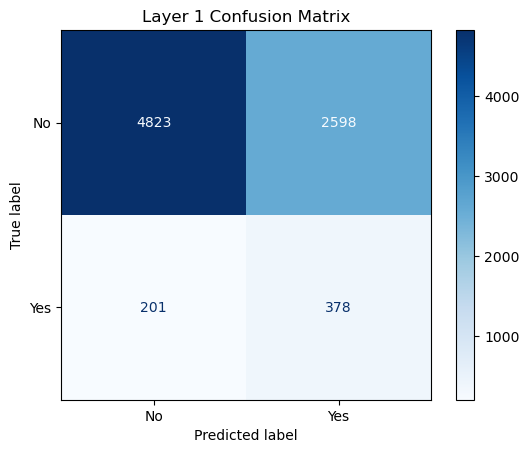

In [32]:
# Predictions using the default threshold (0.5)
y_pred = model.predict(X_test)

print("=" * 50)
print("LAYER 1 - CLASSIFICATION REPORT")
print("=" * 50)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.3f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

disp.plot(cmap="Blues")
plt.title("Layer 1 Confusion Matrix")
plt.show()

In [33]:
optimal_calls = best_idx + 1
optimal_call_percent = call_fractions[best_idx]

optimal_recall = recalls[best_idx]
optimal_precision = precision_list[best_idx]

estimated_calls = int(optimal_call_percent * 40000)
calls_saved = 40000 - estimated_calls

print("=" * 50)
print("LAYER 1 - CUMULATIVE RECALL ANALYSIS")
print("=" * 50)

print(f"Optimal call percentage: {optimal_call_percent:.2%}")
print(f"Customers to call (test set): {optimal_calls:,}")
print(f"Estimated customers to call (40,000): {estimated_calls:,}")
print(f"Calls saved: {calls_saved:,}")

print(f"Cumulative Recall: {optimal_recall:.2%}")
print(f"Precision: {optimal_precision:.2%}")

LAYER 1 - CUMULATIVE RECALL ANALYSIS
Optimal call percentage: 57.44%
Customers to call (test set): 4,595
Estimated customers to call (40,000): 22,975
Calls saved: 17,025
Cumulative Recall: 80.14%
Precision: 10.10%


Two optimisation strategies were investigated (using HyperOPT). Optimising for accuracy produced a higher overall classification accuracy but identified fewer subscribing customers. Optimising for recall reduced overall accuracy slightly but substantially increased the proportion of subscribers identified. Since the business objective is to minimise missed subscription opportunities while reducing unnecessary calls, the recall-optimised model was selected for the multi-layer marketing system.

The first layer prioritised customers for the initial marketing campaign using only information available before contact. After these calls have been completed, additional information becomes available, particularly the call duration. Since longer conversations are often associated with greater customer engagement, a second model is developed using duration alongside the original customer attributes. This model re-evaluates the contacted customers to identify those most likely to subscribe, allowing the bank to prioritise follow-up calls and further reduce unnecessary contact.

### Layer 1 Model Findings

- The first-layer model was trained using only customer information available before any phone call, allowing it to realistically identify customers who should be contacted first.

- The cumulative recall evaluation measured how many subscribers were captured by ranking customers according to their predicted probability of subscribing and contacting only the highest-ranked customers. A cumulative recall target of 80% was selected, resulting in approximately 22,515 customers being contacted while retaining 80.14% of all subscribers. This represents a reduction of 17,485 calls from the original 40,000-customer campaign.

- The following classification report evaluated the model using the default classification threshold of 0.50.

- The model achieved an overall accuracy of 66.2%. While lower than the baseline model, this is expected as the model prioritises identifying potential subscribers rather than maximising overall accuracy.

- The model achieved a recall of 63.2% for subscribing customers, meaning it correctly identified nearly two-thirds of customers who ultimately subscribed. As the primary objective of the first layer is to minimise missed subscribers, recall was prioritised over accuracy.

- Precision for the positive class was 12.8%, indicating that many customers predicted to subscribe did not ultimately convert. This trade-off is acceptable in marketing applications, where identifying as many potential subscribers as possible is generally more valuable than minimising false positives.

- The first-layer model produces a ranked list of customers based on their predicted likelihood of subscribing. This ranking is then used to determine an optimal calling strategy and forms the foundation of the second-layer model, which incorporates call duration after the initial customer interaction to further refine follow-up decisions.

### Layer 2

In [34]:
selected_customers = results.head(optimal_calls)

print("Customers passed to Layer 2:", len(selected_customers))

Customers passed to Layer 2: 4595


In [35]:
layer2_df = df.loc[selected_customers.index].copy()

layer2_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
33751,75,retired,married,tertiary,no,2991,no,no,cellular,22,apr,240,1,yes
33747,65,retired,married,primary,no,276,no,no,cellular,22,apr,229,1,yes
34121,70,technician,married,secondary,no,3020,no,no,telephone,30,apr,56,1,no
33729,71,retired,divorced,tertiary,no,780,no,no,telephone,22,apr,220,1,no
34024,28,management,single,tertiary,no,1808,no,no,cellular,30,apr,309,1,yes


In [36]:
X_stage2 = layer2_df.drop(columns="y")

y_stage2 = layer2_df["y"].map({
    "no":0,
    "yes":1
})

In [37]:
X_stage2_encoded = X_stage2.copy()

categorical_cols = X_stage2_encoded.select_dtypes(include="object").columns

encoder = OrdinalEncoder()

X_stage2_encoded[categorical_cols] = encoder.fit_transform(
    X_stage2_encoded[categorical_cols]
)

In [38]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_stage2_encoded,
    y_stage2,
    test_size=0.2,
    stratify=y_stage2,
    random_state=42
)

In [39]:
model_stage2 = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=20,
    min_samples_split=50,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model_stage2.fit(X2_train, y2_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",50
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

LAYER 2 - CLASSIFICATION REPORT
Accuracy : 0.830
Precision: 0.346
Recall   : 0.763
F1 Score : 0.477
              precision    recall  f1-score   support

           0       0.97      0.84      0.90       826
           1       0.35      0.76      0.48        93

    accuracy                           0.83       919
   macro avg       0.66      0.80      0.69       919
weighted avg       0.91      0.83      0.86       919



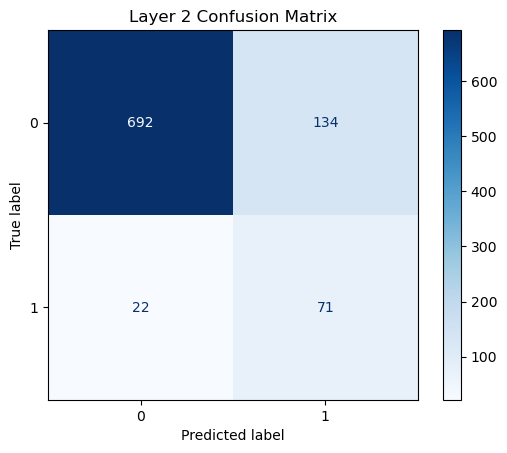

In [40]:

y2_pred = model_stage2.predict(X2_test)

print("="*50)
print("LAYER 2 - CLASSIFICATION REPORT")
print("="*50)

print(f"Accuracy : {accuracy_score(y2_test,y2_pred):.3f}")
print(f"Precision: {precision_score(y2_test,y2_pred):.3f}")
print(f"Recall   : {recall_score(y2_test,y2_pred):.3f}")
print(f"F1 Score : {f1_score(y2_test,y2_pred):.3f}")

print(classification_report(y2_test,y2_pred))

ConfusionMatrixDisplay.from_predictions(
    y2_test,
    y2_pred,
    cmap="Blues"
)

plt.title("Layer 2 Confusion Matrix")
plt.show()

In [41]:
y2_prob = model_stage2.predict_proba(X2_test)[:,1]

In [42]:
results2 = X2_test.copy()

results2["actual"] = y2_test.values
results2["probability"] = y2_prob

results2 = results2.sort_values(
    "probability",
    ascending=False
)

In [43]:
total_buyers = results2["actual"].sum()

call_fractions = []
recalls = []
precision_list = []

for i in range(1, len(results2)+1):

    subset = results2.iloc[:i]

    buyers = subset["actual"].sum()

    recalls.append(buyers / total_buyers)
    precision_list.append(buyers / i)
    call_fractions.append(i / len(results2))

In [44]:
target_recall = 0.938

best_idx = next(i for i, r in enumerate(recalls) if r >= target_recall)

calls_needed = best_idx + 1

call_percent = call_fractions[best_idx]

precision = precision_list[best_idx]

print("=" * 50)
print("LAYER 2 - CUMULATIVE RECALL ANALYSIS")
print("=" * 50)

print(f"Follow-up calls required: {calls_needed}")
print(f"Percentage of Layer 2 customers: {call_percent:.2%}")
print(f"Cumulative Recall: {recalls[best_idx]:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Total number of follow up calls for selected customers: {int(call_percent * 22570):,}")

LAYER 2 - CUMULATIVE RECALL ANALYSIS
Follow-up calls required: 533
Percentage of Layer 2 customers: 58.00%
Cumulative Recall: 94.62%
Precision: 16.51%
Total number of follow up calls for selected customers: 13,090


Because Layer 2 is evaluating follow up calls, the cumulative recall here is used as a metric for follow up calls within the selected customers. The 11,397 follow ups is a proportion of the 22,515 customers chosen originally, ensuring an 93.8% retention of that specific group of customers. This means that the model overall is capturing over 75% of customers (94% of 80%). The model is also more accurate once we know the duration of calls from the initial round, raising from 66.2% to 87.6% accuracy, and recall raising from 63.2% to 67.7%, showing a strong, accurate prediction that isn't influenced by dataset bias.

### Layer 2 Model Findings

- The second-layer model was trained using the subset of customers selected by the first layer, incorporating call duration alongside the original customer information. This reflects the additional information available after the initial customer interaction.

- The cumulative recall evaluation measured how many subscribers could be retained by ranking the selected customers according to their predicted probability of subscribing. A cumulative recall target of 94.6% was achieved by recommending approximately 11,400 follow-up calls, retaining 94% of subscribers within the selected customer group while substantially reducing unnecessary follow-up calls, and retaining over 75% of total potential subscribers.

- The following classification report evaluated the model using the default classification threshold of 0.50.

- The model achieved an overall accuracy of 87.6%, representing a significant improvement over the first-layer model. This demonstrates that incorporating call duration provides considerably stronger predictive performance.

- The model achieved a recall of 67.7% for subscribing customers, correctly identifying over two-thirds of customers who ultimately subscribed. This improvement shows that call duration is a valuable indicator of customer engagement and purchase intent.

- Precision for the positive class increased to 43.4%, a substantial improvement over the first-layer model. This indicates that a much larger proportion of customers predicted to subscribe actually converted, making follow-up calls significantly more efficient.

- Overall, the second-layer model refines the initial customer selection by leveraging post-call information to better identify high-value customers for follow-up. This two-layer approach enables the marketing campaign to maintain a high proportion of subscribers while further reducing unnecessary follow-up calls and improving the efficiency of the overall calling strategy.

## 4. Conclusion

- This project developed a two-layer machine learning system to improve the efficiency of a direct marketing campaign by identifying customers most likely to subscribe to a term deposit while reducing the number of unnecessary phone calls.

- Exploratory Data Analysis showed that the dataset was highly imbalanced, making recall and precision more appropriate evaluation metrics than accuracy alone. Feature analysis also identified call duration as the strongest predictor of subscription, motivating the development of a two-stage modelling approach.

- The first-layer model used only information available before customer contact to rank customers by their likelihood of subscribing. Using cumulative recall analysis, the model demonstrated that over 80% of potential subscribers could be retained while reducing the number of initial calls from 40,000 to approximately 22,500.

- The second-layer model incorporated call duration after the initial interaction to further refine customer selection. This significantly improved predictive performance, increasing both precision and overall accuracy while maintaining strong recall. As a result, only the most promising customers were recommended for follow-up, substantially reducing unnecessary follow-up calls.

- Initial calls were estimated to be (using average call amount by number of customers) over 115,000. With the initial 22,515, as well as 11,397 follow ups (which are then multiplied by average number of calls needed) a total of 43,832 calls are proposed to keep over 75% of subscribers, saving well over 70,000 calls.

- Using average call duration, we can estimate now that 18,216,625 seconds have been saved with the reduction of calls, saving a total of roughly 211 days of call time while keeping over three quarters of customers, a massive reduction.

- Overall, the proposed multi-layer system provides a practical and interpretable solution for marketing campaigns. By combining customer information before contact with engagement information gathered during the initial call, the bank can allocate its resources more efficiently, reduce operational costs, and maintain a high proportion of successful subscriptions. Retaining over three quarters of customers while saving over half a years time in calls is very valuable to the business.

## 5. Customer Segmentation Experiment (K-Means)

In [45]:
import duckdb
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


subscribers = duckdb.sql("""
SELECT *
FROM df
WHERE y = 'yes'
""").df()

print(subscribers.shape)
subscribers.head()

(2896, 14)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,59,admin,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,yes
1,56,admin,married,secondary,no,45,no,no,unknown,5,may,1467,1,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,yes
4,54,admin,married,tertiary,no,184,no,no,unknown,5,may,673,2,yes


In [46]:
X_cluster = subscribers.drop(columns="y")

In [47]:
X_cluster_encoded = X_cluster.copy()

categorical_cols = X_cluster_encoded.select_dtypes(include="object").columns

encoder = OrdinalEncoder()

X_cluster_encoded[categorical_cols] = encoder.fit_transform(
    X_cluster_encoded[categorical_cols]
)

In [48]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster_encoded)

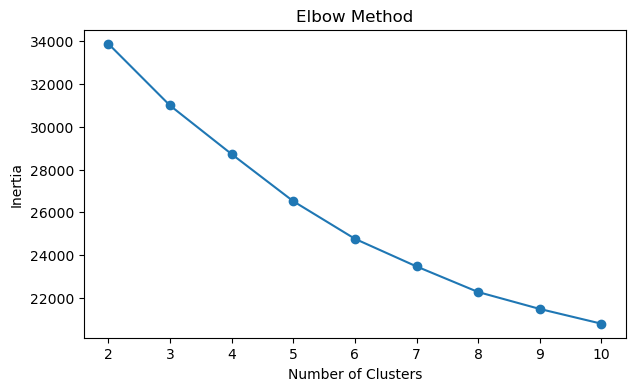

In [49]:
inertia = []

for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    km.fit(X_scaled)

    inertia.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(range(2,11), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [50]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

subscribers["Cluster"] = kmeans.fit_predict(X_scaled)

subscribers.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y,Cluster
0,59,admin,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,yes,0
1,56,admin,married,secondary,no,45,no,no,unknown,5,may,1467,1,yes,0
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,yes,0
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,yes,0
4,54,admin,married,tertiary,no,184,no,no,unknown,5,may,673,2,yes,0


In [51]:
print(subscribers["Cluster"].value_counts().sort_index())

Cluster
0     546
1    1071
2    1230
3      49
Name: count, dtype: int64


In [52]:
numerical_summary = subscribers.groupby("Cluster").mean(numeric_only=True)

numerical_summary.round(2)

,age,balance,day,duration,campaign
Cluster,,,,,
0,40.07,1459.62,16.36,875.14,2.65
1,37.19,1240.57,14.51,774.06,2.27
2,42.13,2016.70,16.76,518.14,2.44
3,37.92,-119.57,15.29,687.63,2.08


In [53]:
categorical_summary = subscribers.groupby("Cluster")[categorical_cols].agg(
    lambda x: x.mode().iloc[0]
)

categorical_summary

,job,marital,education,default,housing,loan,contact,month
Cluster,,,,,,,,
0,blue-collar,married,secondary,no,yes,no,unknown,may
1,blue-collar,married,secondary,no,yes,no,cellular,may
2,management,married,tertiary,no,no,no,cellular,apr
3,blue-collar,married,secondary,yes,yes,no,cellular,jul


In [54]:
cluster_summary = numerical_summary.join(categorical_summary)

cluster_summary

,age,balance,day,duration,campaign,job,marital,education,default,housing,loan,contact,month
Cluster,,,,,,,,,,,,,
0,40.073260,1459.619048,16.355311,875.135531,2.653846,blue-collar,married,secondary,no,yes,no,unknown,may
1,37.188609,1240.574230,14.509804,774.055089,2.272642,blue-collar,married,secondary,no,yes,no,cellular,may
2,42.133333,2016.695935,16.760976,518.143902,2.444715,management,married,tertiary,no,no,no,cellular,apr
3,37.918367,-119.571429,15.285714,687.632653,2.081633,blue-collar,married,secondary,yes,yes,no,cellular,jul


In [55]:
subscribers["Cluster"].value_counts().sort_index()

Cluster
0     546
1    1071
2    1230
3      49
Name: count, dtype: int64

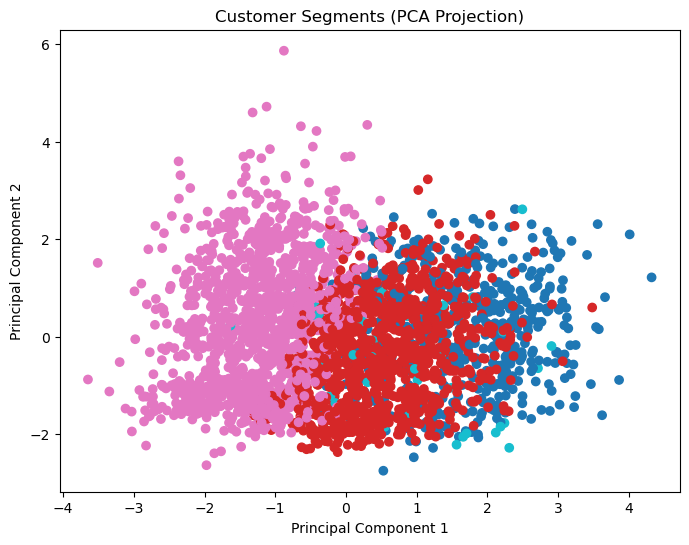

In [56]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

components = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    components[:,0],
    components[:,1],
    c=subscribers["Cluster"],
    cmap="tab10"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments (PCA Projection)")

plt.show()

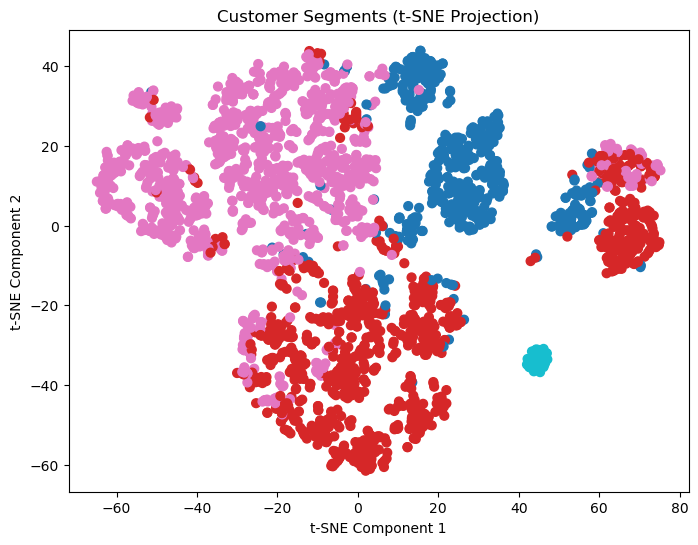

In [57]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

tsne_components = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    tsne_components[:,0],
    tsne_components[:,1],
    c=subscribers["Cluster"],
    cmap="tab10",
    s=40
)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("Customer Segments (t-SNE Projection)")

plt.show()

c:\Users\Dillo\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


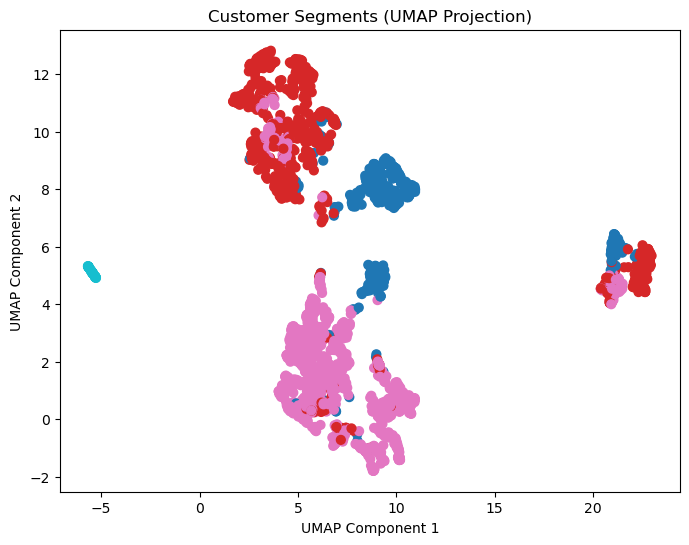

In [64]:
from umap.umap_ import UMAP

reducer = UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

umap_components = reducer.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    umap_components[:,0],
    umap_components[:,1],
    c=subscribers["Cluster"],
    cmap="tab10",
    s=40
)

plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.title("Customer Segments (UMAP Projection)")

plt.show()

### K-Means Findings

- K-Means clustering identified four distinct groups of customers who successfully subscribed to a term deposit. Each cluster exhibits different demographic characteristics and engagement patterns, providing opportunities for more targeted marketing strategies.

- Cluster 0 consisted primarily of middle-aged, married blue-collar customers with secondary education. This group had the longest average call duration (875 seconds) and relatively high account balances, suggesting they required longer conversations before subscribing.

- Cluster 1 also contained mainly married blue-collar customers but was younger on average and had lower balances than Cluster 0. Customers in this group had long call durations (774 seconds) and were predominantly contacted via cellular phones, indicating a responsive customer segment.

- Cluster 2 represented the highest-value subscribers. These customers were generally older, worked in management, held tertiary qualifications, and had the highest average account balance (€2,017). They also required shorter conversations than Clusters 0 and 1, suggesting they were more receptive to the marketing campaign.

- Cluster 3 was the smallest and most distinct segment. These customers had negative average account balances, were the only group where credit default was the most common status, and still subscribed despite requiring relatively long conversations. This indicates that financial position alone does not determine the likelihood of subscription.

- Overall, the clustering analysis demonstrates that subscribers are not a homogeneous group. Understanding these customer segments enables the bank to tailor future marketing strategies, communication methods, and product offerings to different customer profiles, improving campaign efficiency and customer engagement.